In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pickle
import os

In [2]:
def get_smooth(values, gamma):
    result = []
    now = values[0]
    for el in values:
        now = gamma * now + (1 - gamma) * el
        result.append(now)
    return result

In [3]:
def present(files, task = 'test'):
    
    ax = plt.gca()
    for file in files:
        try:
            molecule_name = file.split('/')[-1].split('_')[0]
            
            with open(f'{file}/history.pickle', 'rb') as f:
                data = pickle.load(f)
           

            i = 0
            while True:
                #if i > 0:
                #    break
                if os.path.isdir(f'{file}_continuation_{i}'):
                    try:
                        with open(f'{file}_continuation_{i}/history.pickle', 'rb') as f:
                            now = pickle.load(f)
                    except:
                        break
                    data = data + now
                    i += 1
                else:
                    break
        except:
            pass
        
        grid,  \
        val_mae, train_mae = [], [], []
        
        for i, el in enumerate(data):            
            grid.append(i)
            #print(el.keys())
            val_mae.append(el['forces']['val']['mae'])
            train_mae.append(el['forces']['train']['mae'])            
           

        smooth_val = get_smooth(val_mae, 0.7)
        smooth_train = get_smooth(train_mae, 0.7)
        
        print()
        print(file)
        print("val min: ", np.min(val_mae))
        print("smooth val min: ", np.min(smooth_val))
        print("val last 500: ", np.mean(val_mae[-500:]))
        print("best val pos: ", np.argmin(val_mae) / len(val_mae))
        print("train min: ", np.min(train_mae))
        print("smooth train min: ", np.min(smooth_train))
        print('total epochs: ', len(grid))       
       
        #color = next(ax._get_lines.prop_cycler)['color']
        #plt.plot(grid, smooth_val, label = file + ' val ' + str(smooth_val[-1]))
        #
        if task == 'val':
            plt.plot(grid, smooth_val, label = file + ' val ' + str(np.min(val_mae)))
        if task == 'train':
            plt.plot(grid, smooth_train, label = file + ' train ' + str(smooth_train[-1]))
    plt.plot([np.min(grid), np.max(grid)], [0.0264, 0.0264], color = 'black')
    #plt.vlines(1200, 1e-3, 1)
    plt.yscale('log')
    #plt.xscale('log')
    plt.legend()
    #plt.savefig("histories.pdf", dpi = 300)
    #plt.show()

['results/coll_3_3_seed_0_with_energies_0.03_long']

results/coll_3_3_seed_0_with_energies_0.03_long
val min:  0.02284508
smooth val min:  0.023017461339705662
val last 500:  0.02319333
best val pos:  0.8578804347826087
train min:  0.006072499
smooth train min:  0.006121706753947433
total epochs:  3680


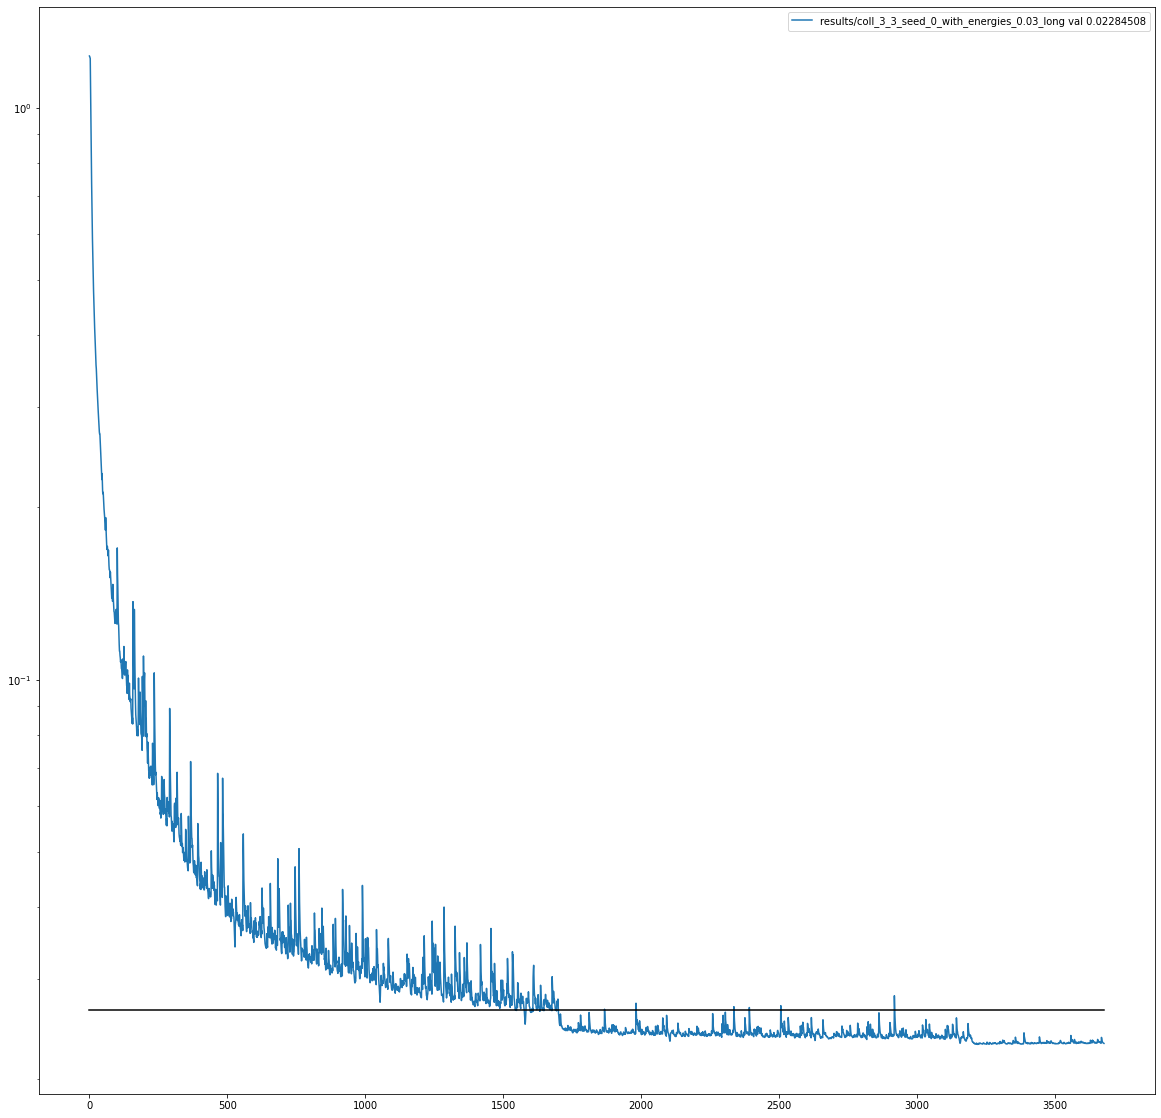

In [4]:
plt.figure(figsize = (20, 20))
files = os.listdir('results/')
#print(files)
files = ['results/' + file for file in files if not file.startswith('.')]
files = [file for file in files if 'continuation' not in file]
print(files)

present(files, task = 'val')